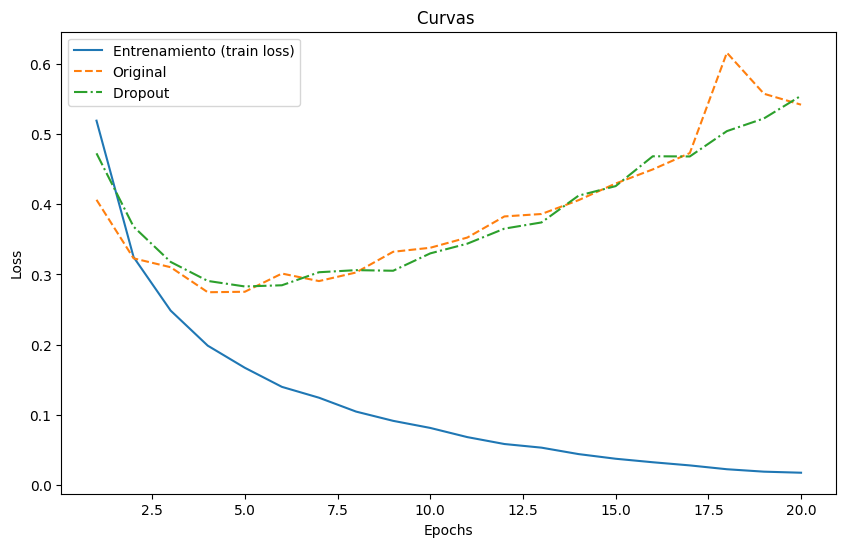

In [12]:
from keras.datasets import imdb
from keras import models, layers, regularizers
import numpy as np
import matplotlib.pyplot as plt


(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000,
    index_from=3
)

def vectorizar(sequences, dim=10000):
    results = np.zeros((len(sequences), dim))
    for i, seq in enumerate(sequences):
        results[i, seq] = 1
    return results

x_train = vectorizar(train_data)
y_train = np.asarray(train_labels).astype('float32')

x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]


model_original = models.Sequential([
    layers.Dense(12, activation='relu', input_shape=(10000,)),
    layers.Dense(12, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_original.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_original = model_original.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=0
)


model_dropout = models.Sequential()

model_dropout.add(layers.Dense(
    12,
    activation='relu',
    input_shape=(10000,),
    kernel_regularizer=regularizers.l1_l2(l1=1e-6, l2=1e-5)
))
model_dropout.add(layers.Dropout(0.2))  #

model_dropout.add(layers.Dense(
    12,
    activation='relu',
    kernel_regularizer=regularizers.l1_l2(l1=1e-6, l2=1e-5)
))
model_dropout.add(layers.Dropout(0.2))

model_dropout.add(layers.Dense(1, activation='sigmoid'))

model_dropout.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_dropout = model_dropout.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=0
)


epoch = range(1, 21)

plt.figure(figsize=(10,6))

# entrenamiento
plt.plot(epoch, history_original.history['loss'],
         label='Entrenamiento (train loss)')

# original validación
plt.plot(epoch, history_original.history['val_loss'],
         '--', label='Original')

# dropout validación
plt.plot(epoch, history_dropout.history['val_loss'],
         '-.', label='Dropout ')

plt.title("Curvas ")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()